# A vs B/C Final Model

This notebook builds and compares binary classifiers for the first stage of the hierarchical segmentation strategy:

- `0`: `SEG_A`
- `1`: `SEG_B/C`

The goal is to identify HCPs that are clearly `SEG_A` versus HCPs that should be routed to the second-stage `SEG_B` vs `SEG_C` model.

The notebook follows this workflow:

1. Load temporal tensor features.
2. Create a binary target from the original 3-class labels.
3. Split data by HCP-level folds to avoid leakage.
4. Compare a temporal CNN against classical ML models.
5. Select the final binary model and threshold.
6. Generate predictions for all HCPs.
7. Save model artifacts and metadata for reuse.

## 1. Imports and configuration

All imports are grouped at the top of the notebook.  
The `SEED` is fixed to make results as reproducible as possible.

In [ ]:
import os
import json
import joblib
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import tensorflow as tf

from tensorflow.keras import layers, models, callbacks, regularizers

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from xgboost import XGBClassifier

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## 2. Paths

In [ ]:
TENSOR_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_tensors")
MODEL_DIR = Path(r"C:\Users\omarl\Downloads\pfizer_models")
OUTPUT_DIR = Path(r"C:\Users\omarl\Documents\pfizer_outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

required_tensor_files = [
    TENSOR_DIR / "X_features.pt",
    TENSOR_DIR / "y_labels.pt",
    TENSOR_DIR / "folds.pt",
]

for file_path in required_tensor_files:
    if not file_path.exists():
        raise FileNotFoundError(f"Missing required tensor file: {file_path}")

## 3. Load tensor data

The input tensor has the following structure:

`HCP × weeks × features`

For classical machine learning models, the tensor will later be flattened into a 2D matrix.

In [ ]:
X_torch = torch.load(TENSOR_DIR / "X_features.pt")
y_torch = torch.load(TENSOR_DIR / "y_labels.pt")
fold_torch = torch.load(TENSOR_DIR / "folds.pt")

X_tf = tf.convert_to_tensor(X_torch.cpu().numpy(), dtype=tf.float32)
y_tf = tf.convert_to_tensor(y_torch.cpu().numpy(), dtype=tf.int64)
fold_tf = tf.convert_to_tensor(fold_torch.cpu().numpy(), dtype=tf.int64)

print("X:", X_tf.shape)
print("y:", y_tf.shape)
print("folds:", fold_tf.shape)

C:\Users\omarl\AppData\Local\Temp\ipykernel_19552\1690075706.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_torch = torch.load(TENSOR_DIR / "X_features.pt")


X: (20931, 86, 65)
y: (20931,)
folds: (20931,)


C:\Users\omarl\AppData\Local\Temp\ipykernel_19552\1690075706.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  y_torch = torch.load(TENSOR_DIR / "y_labels.pt")
C:\Users\om

## 4. Prepare binary target

The original target contains three classes:

- `0`: `SEG_A`
- `1`: `SEG_B`
- `2`: `SEG_C`
- `-1`: unlabeled HCP

For this first-stage model, `SEG_B` and `SEG_C` are combined into a single `SEG_B/C` class.

In [4]:
# Keep only labeled data
labeled_mask = y_tf != -1

X_labeled = tf.boolean_mask(X_tf, labeled_mask)
y_labeled = tf.boolean_mask(y_tf, labeled_mask)
fold_labeled = tf.boolean_mask(fold_tf, labeled_mask)

print("X labeled:", X_labeled.shape)
print("y labeled:", y_labeled.shape)
print("fold labeled:", fold_labeled.shape)

print(pd.Series(y_labeled.numpy()).value_counts().sort_index())

X labeled: (11899, 86, 65)
y labeled: (11899,)
fold labeled: (11899,)
0    6406
1    3349
2    2144
Name: count, dtype: int64


In [5]:
# Define label mapping
label_names_3class = {
    0: "SEG_A",
    1: "SEG_B",
    2: "SEG_C"
}

In [6]:
# Create binary labels for SEG_A vs SEG_B/C
y_binary = tf.cast(y_labeled != 0, tf.int64)

binary_target_names = ["SEG_A", "SEG_BC"]

print(pd.Series(y_binary.numpy()).value_counts().sort_index())

0    6406
1    5493
Name: count, dtype: int64


## 5. Train / validation / test split

The split is done using predefined HCP-level folds.  
This avoids leakage because the same HCP does not appear in both training and test data.

In [7]:
# Fold assignment
test_fold = 3
val_fold = 4

train_mask = (fold_labeled != test_fold) & (fold_labeled != val_fold)
val_mask = fold_labeled == val_fold
test_mask = fold_labeled == test_fold

X_train = tf.boolean_mask(X_labeled, train_mask)
y_train = tf.boolean_mask(y_binary, train_mask)

X_val = tf.boolean_mask(X_labeled, val_mask)
y_val = tf.boolean_mask(y_binary, val_mask)

X_test = tf.boolean_mask(X_labeled, test_mask)
y_test = tf.boolean_mask(y_binary, test_mask)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7140, 86, 65) (7140,)
Val: (2379, 86, 65) (2379,)
Test: (2380, 86, 65) (2380,)


## 6. Flatten tensors for classical machine learning models

Classical models such as Logistic Regression, Random Forest, XGBoost, and HistGradientBoosting expect a 2D tabular input.  
Therefore, the tensor is flattened from:

`HCP × weeks × features`

to:

`HCP × (weeks × features)`

In [ ]:
X_train_flat = X_train.numpy().reshape(X_train.shape[0], -1)
X_val_flat = X_val.numpy().reshape(X_val.shape[0], -1)
X_test_flat = X_test.numpy().reshape(X_test.shape[0], -1)

y_train_np = y_train.numpy()
y_val_np = y_val.numpy()
y_test_np = y_test.numpy()

print("X_train_flat:", X_train_flat.shape)
print("X_val_flat:", X_val_flat.shape)
print("X_test_flat:", X_test_flat.shape)

X_train_flat: (7140, 5590)
X_val_flat: (2379, 5590)
X_test_flat: (2380, 5590)


## 7. Class distribution by split

Before training, the class distribution is checked across train, validation, and test sets.

In [11]:
#Check distribution of classes in each split
def show_distribution(y_tensor, name):
    y_np = y_tensor.numpy()
    counts = pd.Series(y_np).value_counts().sort_index()
    pct = pd.Series(y_np).value_counts(normalize=True).sort_index() * 100
    
    dist = pd.DataFrame({
        "class": [binary_target_names[i] for i in counts.index],
        "count": counts.values,
        "pct": pct.values.round(2)
    })
    
    print(name)
    display(dist)

show_distribution(y_train, "Train")
show_distribution(y_val, "Validation")
show_distribution(y_test, "Test")

Train


,class,count,pct
0,SEG_A,3844,53.84
1,SEG_BC,3296,46.16


Validation


,class,count,pct
0,SEG_A,1281,53.85
1,SEG_BC,1098,46.15


Test


,class,count,pct
0,SEG_A,1281,53.82
1,SEG_BC,1099,46.18


## 8. Evaluation helper functions

These functions are used consistently across all binary models.

The selected decision threshold matters because this first-stage model controls whether an HCP moves forward to the second-stage `SEG_B` vs `SEG_C` model.

In [ ]:
def evaluate_binary_predictions(y_true, y_proba, threshold=0.50, model_name="Model"):
    y_pred = (y_proba >= threshold).astype(int)
    
    report = classification_report(
        y_true,
        y_pred,
        target_names=["SEG_A", "SEG_BC"],
        output_dict=True
    )
    
    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "SEG_A_precision": report["SEG_A"]["precision"],
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_BC_precision": report["SEG_BC"]["precision"],
        "SEG_BC_recall": report["SEG_BC"]["recall"],
        "SEG_BC_f1": report["SEG_BC"]["f1-score"],
    }
    
    return metrics

In [ ]:
def threshold_search_binary(y_true, y_proba, model_name="Model"):
    rows = []
    
    for threshold in np.arange(0.30, 0.71, 0.05):
        rows.append(
            evaluate_binary_predictions(
                y_true=y_true,
                y_proba=y_proba,
                threshold=round(float(threshold), 2),
                model_name=model_name
            )
        )
    
    return pd.DataFrame(rows).sort_values(
        ["macro_f1", "weighted_f1", "SEG_BC_recall"],
        ascending=False
    )

In [ ]:
# Plot confusion matrix with percentages
def plot_confusion_matrix_with_percentages(
    y_true,
    y_pred,
    target_names,
    normalize=True,
    title="Confusion Matrix"
):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm_display = cm / cm.sum(axis=1, keepdims=True)
    else:
        cm_display = cm
    
    plt.figure(figsize=(6, 5))
    plt.imshow(cm_display, aspect="auto")
    plt.colorbar()
    
    plt.xticks(range(len(target_names)), target_names, rotation=45)
    plt.yticks(range(len(target_names)), target_names)
    
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                text = f"{cm_display[i, j]*100:.1f}%\n({cm[i, j]})"
            else:
                text = f"{cm[i, j]}"
            
            plt.text(j, i, text, ha="center", va="center")
    
    plt.tight_layout()
    plt.show()

## 9. Temporal CNN baseline

A temporal CNN is tested because it can learn local patterns across the weekly HCP history.  
This provides a neural-network baseline before comparing against simpler classical models.

In [12]:
# Compute class weights for binary classification
classes = np.unique(y_train.numpy())

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.numpy()
)

class_weight_binary = dict(zip(classes, weights))
class_weight_binary

{0: 0.9287200832466181, 1: 1.083131067961165}

In [13]:
# Get dimensions
n_weeks = X_train.shape[1]
n_features = X_train.shape[2]
n_classes = 2

print("n_weeks:", n_weeks)
print("n_features:", n_features)
print("n_classes:", n_classes)

n_weeks: 86
n_features: 65
n_classes: 2


In [14]:
# Binary CNN
def build_binary_cnn(
    n_weeks,
    n_features,
    learning_rate=3e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4),
    l2_reg=1e-4,
    activation="relu"
):
    d1, d2, d3, d_dense = dropout_config
    
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    
    model = models.Sequential([
        layers.Input(shape=(n_weeks, n_features)),
        
        layers.BatchNormalization(),
        
        layers.Conv1D(
            filters=64,
            kernel_size=3,
            padding="same",
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d1),
        
        layers.Conv1D(
            filters=64,
            kernel_size=5,
            padding="same",
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d2),
        
        layers.Conv1D(
            filters=128,
            kernel_size=3,
            padding="same",
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.BatchNormalization(),
        layers.Dropout(d3),
        
        layers.GlobalAveragePooling1D(),
        
        layers.Dense(
            64,
            activation=activation,
            kernel_regularizer=regularizers.l2(l2_reg)
        ),
        layers.Dropout(d_dense),
        
        layers.Dense(2, activation="softmax")
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [15]:
# Build and summarize the model
binary_cnn = build_binary_cnn(
    n_weeks=n_weeks,
    n_features=n_features,
    learning_rate=3e-4,
    dropout_config=(0.3, 0.3, 0.35, 0.4),
    l2_reg=1e-4,
    activation="relu"
)

binary_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 86, 65)         │           260 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │        12,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 86, 64)         │        20,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 86, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 86, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 86, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 86, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 86, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,462 (263.52 KB)

 Trainable params: 66,820 (261.02 KB)

 Non-trainable params: 642 (2.51 KB)

In [16]:
# Train the model with early stopping and learning rate reduction
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

history_binary_cnn = binary_cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=128,
    class_weight=class_weight_binary,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6636 - loss: 0.6432 - val_accuracy: 0.7394 - val_loss: 0.6309 - learning_rate: 3.0000e-04
Epoch 2/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7345 - loss: 0.5673 - val_accuracy: 0.7461 - val_loss: 0.5918 - learning_rate: 3.0000e-04
Epoch 3/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7483 - loss: 0.5480 - val_accuracy: 0.7499 - val_loss: 0.5633 - learning_rate: 3.0000e-04
Epoch 4/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7541 - loss: 0.5387 - val_accuracy: 0.7524 - val_loss: 0.5451 - learning_rate: 3.0000e-04
Epoch 5/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7591 - loss: 0.5322 - val_accuracy: 0.7579 - val_loss: 0.5304 - learning_rate: 3.0000e-04
Epoch 6/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7609 - loss: 0.5252 - val_accuracy: 0.7612 - val_loss: 0.5250 - learning_rate: 3.0000e-04
Epoch 7/60
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.7703 

In [17]:
# Evaluate the model on the test set
def evaluate_binary_model(model, X_test, y_test, target_names):
    proba = model.predict(X_test)
    y_pred = np.argmax(proba, axis=1)
    y_true = y_test.numpy()
    
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    auc = roc_auc_score(y_true, proba[:, 1])
    
    print("Accuracy:", acc)
    print("Macro F1:", macro_f1)
    print("Weighted F1:", weighted_f1)
    print("ROC AUC:", auc)
    print()
    print(classification_report(
        y_true,
        y_pred,
        target_names=target_names
    ))
    
    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "roc_auc": auc,
        "y_pred": y_pred,
        "proba": proba
    }

binary_results = evaluate_binary_model(
    binary_cnn,
    X_test,
    y_test,
    binary_target_names
)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.7542016806722689
Macro F1: 0.7511161163174195
Weighted F1: 0.7532352586290519
ROC AUC: 0.8298573893376918

              precision    recall  f1-score   support

       SEG_A       0.76      0.80      0.78      1281
      SEG_BC       0.75      0.70      0.72      1099

    accuracy                           0.75      2380
   macro avg       0.75      0.75      0.75      2380
weighted avg       0.75      0.75      0.75      2380



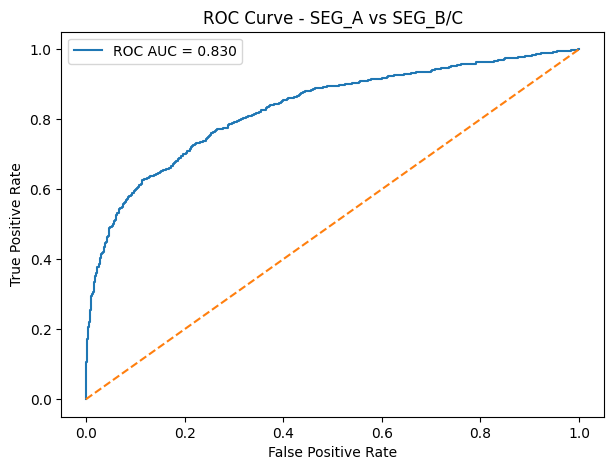

In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test.numpy(),
    binary_results["proba"][:, 1]
)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {binary_results['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SEG_A vs SEG_B/C")
plt.legend()
plt.show()

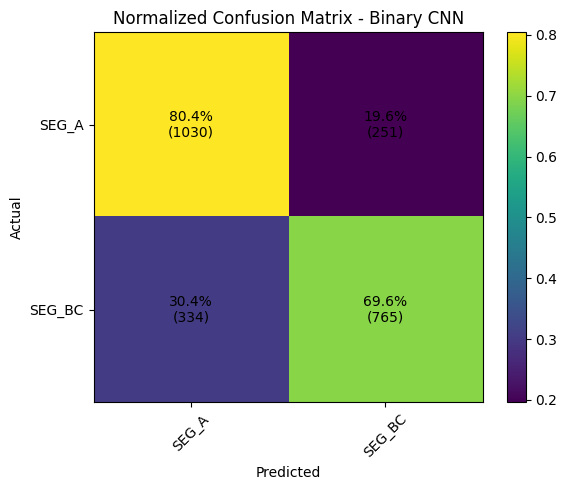

In [ ]:
plot_confusion_matrix_with_percentages(
    y_true=y_test.numpy(),
    y_pred=binary_results["y_pred"],
    target_names=binary_target_names,
    normalize=True,
    title="Normalized Confusion Matrix - Binary CNN"
)

In [20]:
# Evaluate different classification thresholds for the binary model
threshold_results = []

y_true = y_test.numpy()
proba_bc = binary_results["proba"][:, 1]

for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred_t = (proba_bc >= threshold).astype(int)
    
    report = classification_report(
        y_true,
        y_pred_t,
        target_names=binary_target_names,
        output_dict=True
    )
    
    threshold_results.append({
        "threshold_BC": threshold,
        "accuracy": accuracy_score(y_true, y_pred_t),
        "macro_f1": f1_score(y_true, y_pred_t, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred_t, average="weighted"),
        "SEG_A_precision": report["SEG_A"]["precision"],
        "SEG_A_recall": report["SEG_A"]["recall"],
        "SEG_A_f1": report["SEG_A"]["f1-score"],
        "SEG_BC_precision": report["SEG_BC"]["precision"],
        "SEG_BC_recall": report["SEG_BC"]["recall"],
        "SEG_BC_f1": report["SEG_BC"]["f1-score"]
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values("macro_f1", ascending=False)

,threshold_BC,accuracy,macro_f1,weighted_f1,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
6,0.60,0.763445,0.755347,0.758751,0.734334,0.878220,0.799858,0.816038,0.629663,0.710837
4,0.50,0.754202,0.751116,0.753235,0.755132,0.804059,0.778828,0.752953,0.696087,0.723404
7,0.65,0.760504,0.749538,0.753546,0.722605,0.900859,0.801946,0.837803,0.596906,0.697131
3,0.45,0.749160,0.747978,0.749297,0.770998,0.759563,0.765238,0.724508,0.737034,0.730717
5,0.55,0.753361,0.747941,0.750768,0.739641,0.836066,0.784903,0.774678,0.656961,0.710980
2,0.40,0.744958,0.744756,0.745305,0.789022,0.718189,0.751941,0.702636,0.776160,0.737570
8,0.70,0.755042,0.739970,0.744757,0.708732,0.925059,0.802574,0.864407,0.556870,0.677366
1,0.35,0.731092,0.730983,0.730568,0.804948,0.660422,0.725557,0.672686,0.813467,0.736409
0,0.30,0.706723,0.704006,0.701838,0.834673,0.567525,0.675651,0.632869,0.868972,0.732362


In [ ]:
cnn_val_proba = binary_cnn.predict(X_val)[:, 1]
cnn_test_proba = binary_cnn.predict(X_test)[:, 1]

cnn_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=cnn_val_proba,
    model_name="Binary CNN"
)

cnn_thresholds.head(10)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
3,Binary CNN,0.45,0.765448,0.763926,0.765384,0.841073,0.780450,0.785324,0.782879,0.747706,0.742259,0.744973
6,Binary CNN,0.60,0.768810,0.759952,0.763499,0.841073,0.735048,0.892272,0.806065,0.832524,0.624772,0.713840
4,Binary CNN,0.50,0.763766,0.759871,0.762224,0.841073,0.756602,0.827479,0.790455,0.774029,0.689435,0.729287
5,Binary CNN,0.55,0.762085,0.755956,0.758931,0.841073,0.742373,0.854801,0.794630,0.794248,0.653916,0.717283
2,Binary CNN,0.40,0.752417,0.752238,0.752750,0.841073,0.797762,0.723653,0.758903,0.709121,0.785974,0.745572
7,Binary CNN,0.65,0.759142,0.745956,0.750408,0.841073,0.715854,0.916472,0.803834,0.855210,0.575592,0.688078
1,Binary CNN,0.35,0.738546,0.738452,0.738071,0.841073,0.812915,0.668228,0.733505,0.679487,0.820583,0.743399
8,Binary CNN,0.70,0.752417,0.735358,0.740527,0.841073,0.703290,0.934426,0.802548,0.875923,0.540073,0.668169
0,Binary CNN,0.30,0.712484,0.710579,0.708773,0.841073,0.829834,0.586261,0.687100,0.640434,0.859745,0.734059


## 10. Classical model comparison

The same flattened tensor features are used to compare several non-neural models:

- Logistic Regression
- Random Forest
- Extra Trees
- XGBoost
- HistGradientBoosting

The final model is selected using validation metrics and then evaluated on the test set.

In [ ]:
logreg_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        solver="saga",
        penalty="l2",
        C=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

logreg_model.fit(X_train_flat, y_train_np)

logreg_val_proba = logreg_model.predict_proba(X_val_flat)[:, 1]
logreg_test_proba = logreg_model.predict_proba(X_test_flat)[:, 1]

logreg_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=logreg_val_proba,
    model_name="Logistic Regression"
)

logreg_thresholds.head(10)

c:\Users\omarl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
2,Logistic Regression,0.40,0.727617,0.725923,0.727580,0.787037,0.746304,0.748634,0.747467,0.705667,0.703097,0.704380
4,Logistic Regression,0.50,0.728878,0.722880,0.726016,0.787037,0.719613,0.813427,0.763650,0.743287,0.630237,0.682109
3,Logistic Regression,0.45,0.725935,0.722224,0.724694,0.787037,0.729060,0.781421,0.754333,0.721670,0.661202,0.690114
5,Logistic Regression,0.55,0.725095,0.717056,0.720724,0.787037,0.709139,0.829820,0.764748,0.752273,0.602914,0.669363
1,Logistic Regression,0.35,0.713325,0.712867,0.713749,0.787037,0.751048,0.699454,0.724333,0.675379,0.729508,0.701401
6,Logistic Regression,0.60,0.723413,0.712622,0.716906,0.787037,0.699808,0.851678,0.768310,0.768293,0.573770,0.656934
7,Logistic Regression,0.65,0.725515,0.711854,0.716680,0.787037,0.694307,0.875878,0.774594,0.791612,0.550091,0.649113
8,Logistic Regression,0.70,0.724674,0.708278,0.713598,0.787037,0.688327,0.893052,0.777438,0.808926,0.528233,0.639118
0,Logistic Regression,0.30,0.702396,0.702396,0.702406,0.787037,0.760692,0.652615,0.702521,0.652344,0.760474,0.702271


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_flat, y_train_np)

rf_val_proba = rf_model.predict_proba(X_val_flat)[:, 1]
rf_test_proba = rf_model.predict_proba(X_test_flat)[:, 1]

rf_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=rf_val_proba,
    model_name="Random Forest"
)

rf_thresholds.head(10)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
3,Random Forest,0.45,0.752417,0.751743,0.752738,0.83238,0.783142,0.747073,0.764682,0.719965,0.758652,0.738803
4,Random Forest,0.50,0.751156,0.747686,0.749962,0.83238,0.750182,0.806401,0.777276,0.752495,0.686703,0.718095
2,Random Forest,0.40,0.741068,0.741039,0.740830,0.83238,0.809879,0.678376,0.738318,0.684533,0.814208,0.743760
5,Random Forest,0.55,0.746112,0.738379,0.741839,0.83238,0.724618,0.852459,0.783357,0.783257,0.622040,0.693401
6,Random Forest,0.60,0.744430,0.731136,0.735735,0.83238,0.706822,0.897736,0.790922,0.825798,0.565574,0.671351
1,Random Forest,0.35,0.715427,0.713714,0.712011,0.83238,0.830416,0.592506,0.691572,0.643686,0.858834,0.735856
7,Random Forest,0.65,0.732240,0.712184,0.718029,0.83238,0.686559,0.925059,0.788161,0.852986,0.507286,0.636208
8,Random Forest,0.70,0.723413,0.695610,0.702686,0.83238,0.671436,0.952381,0.787605,0.891459,0.456284,0.603614
0,Random Forest,0.30,0.688104,0.682098,0.678737,0.83238,0.849546,0.511319,0.638402,0.610697,0.894353,0.725795


In [ ]:
et_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train_flat, y_train_np)

et_val_proba = et_model.predict_proba(X_val_flat)[:, 1]
et_test_proba = et_model.predict_proba(X_test_flat)[:, 1]

et_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=et_val_proba,
    model_name="Extra Trees"
)

et_thresholds.head(10)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
4,Extra Trees,0.50,0.759563,0.756354,0.758505,0.834349,0.758570,0.811866,0.784314,0.760913,0.698543,0.728395
3,Extra Trees,0.45,0.752837,0.752062,0.753129,0.834349,0.781478,0.750976,0.765924,0.722125,0.755009,0.738201
2,Extra Trees,0.40,0.745271,0.745267,0.745193,0.834349,0.809917,0.688525,0.744304,0.690698,0.811475,0.746231
5,Extra Trees,0.55,0.748634,0.740745,0.744224,0.834349,0.725711,0.857143,0.785970,0.788684,0.622040,0.695519
6,Extra Trees,0.60,0.744010,0.730535,0.735170,0.834349,0.706135,0.898517,0.790794,0.826435,0.563752,0.670276
1,Extra Trees,0.35,0.722993,0.721734,0.720295,0.834349,0.831557,0.608899,0.703019,0.652325,0.856102,0.740449
7,Extra Trees,0.65,0.731400,0.711555,0.717375,0.834349,0.686411,0.922717,0.787213,0.849315,0.508197,0.635897
8,Extra Trees,0.70,0.718789,0.689735,0.697039,0.834349,0.667579,0.951600,0.784680,0.887884,0.447177,0.594791
0,Extra Trees,0.30,0.687684,0.681707,0.678352,0.834349,0.848446,0.511319,0.638091,0.610454,0.893443,0.725323


In [ ]:
xgb_sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_np
)

xgb_model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=400,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=5,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(
    X_train_flat,
    y_train_np,
    sample_weight=xgb_sample_weights
)

xgb_val_proba = xgb_model.predict_proba(X_val_flat)[:, 1]
xgb_test_proba = xgb_model.predict_proba(X_test_flat)[:, 1]

xgb_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=xgb_val_proba,
    model_name="XGBoost"
)

xgb_thresholds.head(10)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
2,XGBoost,0.40,0.765448,0.764879,0.765768,0.845905,0.797531,0.756440,0.776442,0.731959,0.775956,0.753316
4,XGBoost,0.50,0.766709,0.762939,0.765238,0.845905,0.759657,0.829040,0.792833,0.776758,0.693989,0.733045
3,XGBoost,0.45,0.761665,0.759720,0.761383,0.845905,0.772104,0.790788,0.781334,0.748828,0.727687,0.738106
5,XGBoost,0.55,0.765448,0.759140,0.762138,0.845905,0.743763,0.861046,0.798119,0.801339,0.653916,0.720160
6,XGBoost,0.60,0.759142,0.749872,0.753576,0.845905,0.727506,0.883685,0.798026,0.818955,0.613843,0.701718
1,XGBoost,0.35,0.746112,0.746088,0.745899,0.845905,0.814884,0.683841,0.743633,0.689417,0.818761,0.748543
7,XGBoost,0.65,0.755359,0.742835,0.747201,0.845905,0.715342,0.906323,0.799587,0.841270,0.579235,0.686084
8,XGBoost,0.70,0.746532,0.729437,0.734668,0.845905,0.699882,0.926620,0.797447,0.862372,0.536430,0.661426
0,XGBoost,0.30,0.728037,0.726574,0.725036,0.845905,0.843074,0.608119,0.706576,0.654983,0.867942,0.746573


In [ ]:
hgb_model = HistGradientBoostingClassifier(
    learning_rate=0.03,
    max_iter=300,
    max_leaf_nodes=31,
    l2_regularization=1.0,
    random_state=42
)

hgb_model.fit(X_train_flat, y_train_np)

hgb_val_proba = hgb_model.predict_proba(X_val_flat)[:, 1]
hgb_test_proba = hgb_model.predict_proba(X_test_flat)[:, 1]

hgb_thresholds = threshold_search_binary(
    y_true=y_val_np,
    y_proba=hgb_val_proba,
    model_name="HistGradientBoosting"
)

hgb_thresholds.head(10)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
3,HistGradientBoosting,0.45,0.772594,0.770136,0.771964,0.845573,0.775298,0.813427,0.793905,0.769082,0.724954,0.746367
4,HistGradientBoosting,0.50,0.773855,0.769714,0.772089,0.845573,0.762174,0.843091,0.800593,0.791060,0.693078,0.738835
5,HistGradientBoosting,0.55,0.770071,0.764116,0.766999,0.845573,0.748645,0.862607,0.801596,0.805094,0.662113,0.726637
2,HistGradientBoosting,0.40,0.765027,0.764064,0.765224,0.845573,0.788800,0.769711,0.779139,0.738707,0.759563,0.748990
6,HistGradientBoosting,0.60,0.765868,0.757418,0.760901,0.845573,0.734760,0.884465,0.802692,0.823178,0.627505,0.712145
1,HistGradientBoosting,0.35,0.754939,0.754750,0.755274,0.845573,0.799828,0.726776,0.761554,0.711934,0.787796,0.747946
7,HistGradientBoosting,0.65,0.759563,0.747933,0.752098,0.845573,0.720323,0.904762,0.802076,0.841558,0.590164,0.693790
8,HistGradientBoosting,0.70,0.754939,0.739791,0.744620,0.845573,0.708732,0.925059,0.802574,0.864215,0.556466,0.677008
0,HistGradientBoosting,0.30,0.730559,0.730376,0.729835,0.845573,0.808880,0.654176,0.723349,0.670141,0.819672,0.737403


## 11. Model selection

The model is selected using validation performance.  
A custom score is also computed to balance:

- Macro F1
- ROC AUC
- `SEG_B/C` recall

In [ ]:
all_threshold_results_val = pd.concat([
    cnn_thresholds,
    logreg_thresholds,
    rf_thresholds,
    et_thresholds,
    xgb_thresholds,
    hgb_thresholds
], ignore_index=True)

all_threshold_results_val.sort_values(
    ["macro_f1", "roc_auc", "SEG_BC_recall"],
    ascending=False
).head(20)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1
45,HistGradientBoosting,0.45,0.772594,0.770136,0.771964,0.845573,0.775298,0.813427,0.793905,0.769082,0.724954,0.746367
46,HistGradientBoosting,0.50,0.773855,0.769714,0.772089,0.845573,0.762174,0.843091,0.800593,0.791060,0.693078,0.738835
36,XGBoost,0.40,0.765448,0.764879,0.765768,0.845905,0.797531,0.756440,0.776442,0.731959,0.775956,0.753316
47,HistGradientBoosting,0.55,0.770071,0.764116,0.766999,0.845573,0.748645,0.862607,0.801596,0.805094,0.662113,0.726637
48,HistGradientBoosting,0.40,0.765027,0.764064,0.765224,0.845573,0.788800,0.769711,0.779139,0.738707,0.759563,0.748990
0,Binary CNN,0.45,0.765448,0.763926,0.765384,0.841073,0.780450,0.785324,0.782879,0.747706,0.742259,0.744973
37,XGBoost,0.50,0.766709,0.762939,0.765238,0.845905,0.759657,0.829040,0.792833,0.776758,0.693989,0.733045
1,Binary CNN,0.60,0.768810,0.759952,0.763499,0.841073,0.735048,0.892272,0.806065,0.832524,0.624772,0.713840
2,Binary CNN,0.50,0.763766,0.759871,0.762224,0.841073,0.756602,0.827479,0.790455,0.774029,0.689435,0.729287
38,XGBoost,0.45,0.761665,0.759720,0.761383,0.845905,0.772104,0.790788,0.781334,0.748828,0.727687,0.738106


In [ ]:
all_threshold_results_val["custom_score"] = (
    0.40 * all_threshold_results_val["macro_f1"] +
    0.30 * all_threshold_results_val["roc_auc"] +
    0.30 * all_threshold_results_val["SEG_BC_recall"]
)

all_threshold_results_val.sort_values(
    "custom_score",
    ascending=False
).head(20)

,model,threshold,accuracy,macro_f1,weighted_f1,roc_auc,SEG_A_precision,SEG_A_recall,SEG_A_f1,SEG_BC_precision,SEG_BC_recall,SEG_BC_f1,custom_score
44,XGBoost,0.30,0.728037,0.726574,0.725036,0.845905,0.843074,0.608119,0.706576,0.654983,0.867942,0.746573,0.804784
41,XGBoost,0.35,0.746112,0.746088,0.745899,0.845905,0.814884,0.683841,0.743633,0.689417,0.818761,0.748543,0.797835
32,Extra Trees,0.35,0.722993,0.721734,0.720295,0.834349,0.831557,0.608899,0.703019,0.652325,0.856102,0.740449,0.795829
8,Binary CNN,0.30,0.712484,0.710579,0.708773,0.841073,0.829834,0.586261,0.687100,0.640434,0.859745,0.734059,0.794477
6,Binary CNN,0.35,0.738546,0.738452,0.738071,0.841073,0.812915,0.668228,0.733505,0.679487,0.820583,0.743399,0.793878
23,Random Forest,0.35,0.715427,0.713714,0.712011,0.832380,0.830416,0.592506,0.691572,0.643686,0.858834,0.735856,0.792850
36,XGBoost,0.40,0.765448,0.764879,0.765768,0.845905,0.797531,0.756440,0.776442,0.731959,0.775956,0.753316,0.792510
50,HistGradientBoosting,0.35,0.754939,0.754750,0.755274,0.845573,0.799828,0.726776,0.761554,0.711934,0.787796,0.747946,0.791911
29,Extra Trees,0.40,0.745271,0.745267,0.745193,0.834349,0.809917,0.688525,0.744304,0.690698,0.811475,0.746231,0.791854
53,HistGradientBoosting,0.30,0.730559,0.730376,0.729835,0.845573,0.808880,0.654176,0.723349,0.670141,0.819672,0.737403,0.791724


## 12. Final model evaluation

The selected final model is `HistGradientBoosting` with a decision threshold of `0.45`.

This threshold is important because the model outputs probabilities. The threshold converts `P(SEG_B/C)` into the final binary prediction.

In [ ]:
best_model_name = "HistGradientBoosting"
best_threshold = 0.45

In [ ]:
test_proba_dict = {
    "Binary CNN": cnn_test_proba,
    "Logistic Regression": logreg_test_proba,
    "Random Forest": rf_test_proba,
    "Extra Trees": et_test_proba,
    "XGBoost": xgb_test_proba,
    "HistGradientBoosting": hgb_test_proba,
}

best_test_proba = test_proba_dict[best_model_name]

best_test_metrics = evaluate_binary_predictions(
    y_true=y_test_np,
    y_proba=best_test_proba,
    threshold=best_threshold,
    model_name=best_model_name
)

best_test_metrics

{'model': 'HistGradientBoosting',
 'threshold': 0.45,
 'accuracy': 0.7722689075630252,
 'macro_f1': 0.7703775750550399,
 'weighted_f1': 0.7719711978163979,
 'roc_auc': 0.8518300292864351,
 'SEG_A_precision': 0.7809885931558935,
 'SEG_A_recall': 0.8017174082747853,
 'SEG_A_f1': 0.7912172573189522,
 'SEG_BC_precision': 0.7615023474178404,
 'SEG_BC_recall': 0.737943585077343,
 'SEG_BC_f1': 0.7495378927911276}

In [ ]:
best_test_pred = (best_test_proba >= best_threshold).astype(int)

print(classification_report(
    y_test_np,
    best_test_pred,
    target_names=["SEG_A", "SEG_BC"]
))

print("ROC AUC:", roc_auc_score(y_test_np, best_test_proba))

              precision    recall  f1-score   support

       SEG_A       0.78      0.80      0.79      1281
      SEG_BC       0.76      0.74      0.75      1099

    accuracy                           0.77      2380
   macro avg       0.77      0.77      0.77      2380
weighted avg       0.77      0.77      0.77      2380

ROC AUC: 0.8518300292864351


## 13. Generate predictions for all HCPs

The final model is applied to all HCPs, including labeled and unlabeled cases.  
If a tensor manifest exists, the HCP ID is added to the prediction output.

In [ ]:
X_all_flat = X_tf.numpy().reshape(X_tf.shape[0], -1)
y_all_np = y_tf.numpy()
fold_all_np = fold_tf.numpy()

In [ ]:
if best_model_name == "Binary CNN":
    all_proba_bc = binary_cnn.predict(X_tf)[:, 1]
else:
    model_dict = {
        "Logistic Regression": logreg_model,
        "Random Forest": rf_model,
        "Extra Trees": et_model,
        "XGBoost": xgb_model,
        "HistGradientBoosting": hgb_model,
    }
    
    best_model = model_dict[best_model_name]
    all_proba_bc = best_model.predict_proba(X_all_flat)[:, 1]

In [ ]:
all_pred_binary = (all_proba_bc >= best_threshold).astype(int)

pred_label = np.where(all_pred_binary == 0, "SEG_A", "SEG_BC")
true_label = np.where(
    y_all_np == 0, "SEG_A",
    np.where(y_all_np == 1, "SEG_B",
    np.where(y_all_np == 2, "SEG_C", "UNLABELED"))
)

result_predictions_df = pd.DataFrame({
    "true_label_original": true_label,
    "true_label_encoded": y_all_np,
    "hcp_fold": fold_all_np,
    "prob_SEG_BC": all_proba_bc,
    "prob_SEG_A": 1 - all_proba_bc,
    "pred_binary_encoded": all_pred_binary,
    "pred_binary_label": pred_label,
    "decision_threshold": best_threshold,
    "model_name": best_model_name
})

result_predictions_df.head()

,true_label_original,true_label_encoded,hcp_fold,prob_SEG_BC,prob_SEG_A,pred_binary_encoded,pred_binary_label,decision_threshold,model_name
0,UNLABELED,-1,-1,0.110811,0.889189,0,SEG_A,0.45,HistGradientBoosting
1,UNLABELED,-1,-1,0.090831,0.909169,0,SEG_A,0.45,HistGradientBoosting
2,SEG_A,0,1,0.128401,0.871599,0,SEG_A,0.45,HistGradientBoosting
3,UNLABELED,-1,-1,0.089550,0.910450,0,SEG_A,0.45,HistGradientBoosting
4,UNLABELED,-1,-1,0.219840,0.780160,0,SEG_A,0.45,HistGradientBoosting


In [ ]:
manifest_path = TENSOR_DIR / "tensor_manifest.csv"

if manifest_path.exists():
    manifest_df = pd.read_csv(manifest_path)
    result_predictions_df = pd.concat(
        [manifest_df.reset_index(drop=True), result_predictions_df.reset_index(drop=True)],
        axis=1
    )

result_predictions_df.head()

,true_label_original,true_label_encoded,hcp_fold,prob_SEG_BC,prob_SEG_A,pred_binary_encoded,pred_binary_label,decision_threshold,model_name
0,UNLABELED,-1,-1,0.110811,0.889189,0,SEG_A,0.45,HistGradientBoosting
1,UNLABELED,-1,-1,0.090831,0.909169,0,SEG_A,0.45,HistGradientBoosting
2,SEG_A,0,1,0.128401,0.871599,0,SEG_A,0.45,HistGradientBoosting
3,UNLABELED,-1,-1,0.089550,0.910450,0,SEG_A,0.45,HistGradientBoosting
4,UNLABELED,-1,-1,0.219840,0.780160,0,SEG_A,0.45,HistGradientBoosting


## 14. Save model artifacts

The `.joblib` file stores the trained model, while the metadata JSON stores the threshold, label mapping, and test metrics.

Both files are needed to reuse the model correctly.

In [ ]:
output_path = OUTPUT_DIR / "binary_segA_vs_segBC_predictions.csv"

result_predictions_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: C:\Users\omarl\Documents\pfizer_outputs\binary_segA_vs_segBC_predictions.csv


In [ ]:
if best_model_name != "Binary CNN":
    joblib.dump(best_model, MODEL_DIR / "best_binary_segA_vs_segBC.joblib")

metadata = {
    "best_model_name": best_model_name,
    "best_threshold": best_threshold,
    "task": "SEG_A vs SEG_BC",
    "label_mapping": {
        "0": "SEG_A",
        "1": "SEG_BC"
    },
    "test_metrics": best_test_metrics
}

with open(MODEL_DIR / "model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

all_threshold_results_val.to_csv(
    MODEL_DIR / "binary_model_threshold_comparison_validation.csv",
    index=False
)

## 15. Final notes

The selected binary model is used as the first stage of the hierarchical segmentation pipeline.  
Its output probability `prob_SEG_BC` determines whether an HCP should remain classified as `SEG_A` or be routed to the second-stage `SEG_B` vs `SEG_C` model.

The selected threshold should always be loaded from metadata when reusing the model.